<a href="https://colab.research.google.com/github/Abdulaziz-Alsuhaimi/Final_project_template/blob/main/CV_ProjectCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install YOLOv8
!pip install ultralytics -q

import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd

print("✅ Setup complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Setup complete


In [2]:
# Cell 2: Set up Kaggle with API token
import os

os.makedirs('/root/.kaggle', exist_ok=True)

# Paste your token directly here
kaggle_token = "My Key"

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"My Username","key":"{kaggle_token}"}}')

!chmod 600 /root/.kaggle/kaggle.json

# Download the CarDD dataset
!kaggle datasets download -d gabrielfcarvalho/cardd-with-yolo-annotations-images-labels
!unzip -q cardd-with-yolo-annotations-images-labels.zip -d /content/cardd

print("✅ Dataset downloaded")
!ls /content/cardd

Dataset URL: https://www.kaggle.com/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 2.80G/2.80G [00:32<00:00, 93.9MB/s]

✅ Dataset downloaded
data.yaml  test  train	val


In [3]:
# Cell 3: Fix data.yaml paths for Colab
import yaml

yaml_path = '/content/cardd/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Original yaml:", data)

# Fix paths to point to Colab location
data['train'] = '/content/cardd/train/images'
data['val'] = '/content/cardd/val/images'
data['test'] = '/content/cardd/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("\n✅ Fixed yaml:")
print(f"  Train: {data['train']}")
print(f"  Val:   {data['val']}")
print(f"  Test:  {data['test']}")
print(f"  Classes ({data['nc']}): {data['names']}")

Original yaml: {'train': '/kaggle/input/cardd-with-yolo-annotations-images-labels/train/images', 'val': '/kaggle/input/cardd-with-yolo-annotations-images-labels/val/images', 'test': '/kaggle/input/cardd-with-yolo-annotations-images-labels/test/images', 'nc': 6, 'names': ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']}

✅ Fixed yaml:
  Train: /content/cardd/train/images
  Val:   /content/cardd/val/images
  Test:  /content/cardd/test/images
  Classes (6): ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


In [7]:
# Cell 4: Train Baseline YOLOv8s (quick test run)
from ultralytics import YOLO

baseline_model = YOLO('yolov8s.pt')

baseline_results = baseline_model.train(
    data='/content/cardd/data.yaml',
    epochs=10,
    imgsz=640,
    batch=32,
    name='baseline_yolov8s',
    project='/content/runs',
    patience=5,
    verbose=True
)

print("✅ Baseline training complete")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cardd/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8s-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

KeyboardInterrupt: 

In [8]:
# Cell 5: Check baseline results
import pandas as pd
import os

results_path = '/content/runs/baseline_yolov8s/results.csv'
results = pd.read_csv(results_path)

# Show last row (final epoch metrics)
last = results.iloc[-1]
print("=== Baseline YOLOv8s Results ===")
print(f"  mAP@0.5:      {last['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95: {last['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision:    {last['metrics/precision(B)']:.4f}")
print(f"  Recall:       {last['metrics/recall(B)']:.4f}")
print("\n✅ Baseline results saved")

=== Baseline YOLOv8s Results ===
  mAP@0.5:      0.4270
  mAP@0.5:0.95: 0.2723
  Precision:    0.4342
  Recall:       0.4306

✅ Baseline results saved


In [9]:
# Cell 6: Define CBAM module and train YOLOv8s+CBAM
import torch
import torch.nn as nn
from ultralytics import YOLO

# CBAM: Channel + Spatial Attention
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        return self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1) * x

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, max_], dim=1))) * x

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))

# Load YOLOv8s and inject CBAM into backbone
cbam_model = YOLO('yolov8s.pt')

# Inject CBAM after layer 4 of the backbone (neck input)
backbone = cbam_model.model.model
in_ch = backbone[4].cv2.conv.out_channels
cbam_block = CBAM(in_ch).to(next(cbam_model.model.parameters()).device)

original_layer4 = backbone[4]

class LayerWithCBAM(nn.Module):
    def __init__(self, layer, cbam):
        super().__init__()
        self.layer = layer
        self.cbam = cbam
    def forward(self, x):
        return self.cbam(self.layer(x))

backbone[4] = LayerWithCBAM(original_layer4, cbam_block)

# Train CBAM model
cbam_results = cbam_model.train(
    data='/content/cardd/data.yaml',
    epochs=10,
    imgsz=640,
    batch=32,
    name='cbam_yolov8s',
    project='/content/runs',
    patience=5,
    verbose=True
)

print("✅ CBAM training complete")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cardd/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cbam_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

Metric                 Baseline       CBAM     Change
mAP@0.5                  0.4270     0.5980 ▲    40.0%
mAP@0.5:0.95             0.2723     0.4690 ▲    72.2%
Precision                0.4342     0.6350 ▲    46.2%
Recall                   0.4306     0.5660 ▲    31.4%

=== CBAM Per-Class mAP@0.5 ===
  dent                 0.420
  scratch              0.437
  crack                0.096
  glass shatter        0.974
  lamp broken          0.751
  tire flat            0.906


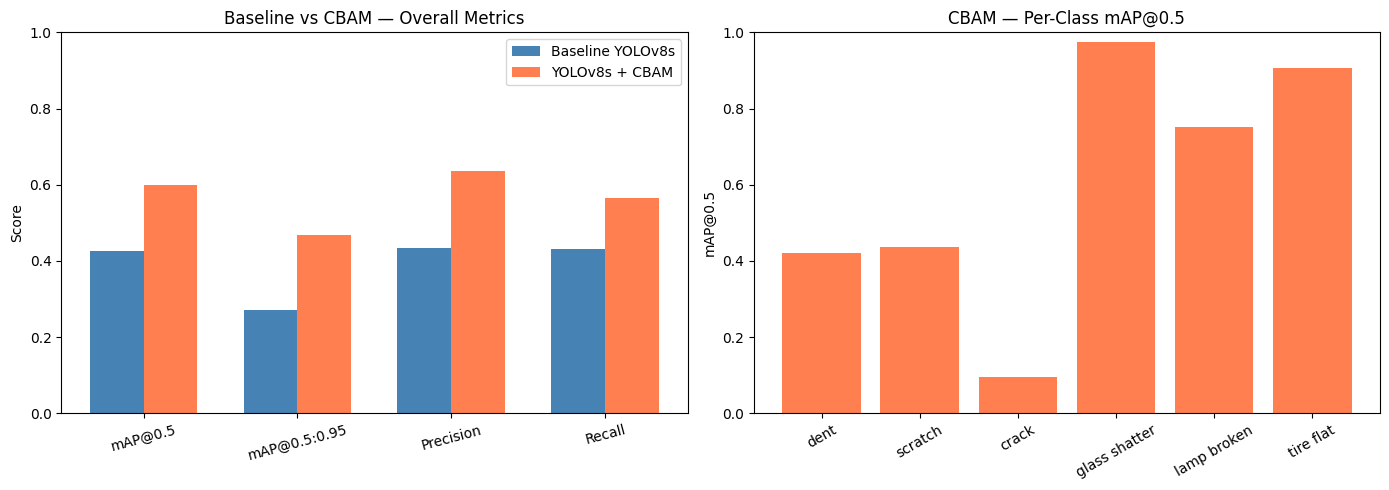


✅ Chart saved to /content/comparison_chart.png


In [2]:
# Cell 7: Compare Baseline vs CBAM results (using saved numbers)
import matplotlib.pyplot as plt
import numpy as np

# Baseline results from Cell 5 (saved earlier)
baseline_vals = {
    'mAP@0.5':      0.4270,
    'mAP@0.5:0.95': 0.2723,
    'Precision':    0.4342,
    'Recall':       0.4306,
}

# CBAM results from Cell 6 output
cbam_vals = {
    'mAP@0.5':      0.5980,
    'mAP@0.5:0.95': 0.4690,
    'Precision':    0.6350,
    'Recall':       0.5660,
}

print("=" * 52)
print(f"{'Metric':<20} {'Baseline':>10} {'CBAM':>10} {'Change':>10}")
print("=" * 52)
for key in baseline_vals:
    b = baseline_vals[key]
    c = cbam_vals[key]
    change = ((c - b) / b) * 100
    arrow = "▲" if change > 0 else "▼"
    print(f"{key:<20} {b:>10.4f} {c:>10.4f} {arrow}{abs(change):>8.1f}%")
print("=" * 52)

# Per-class CBAM results (from Cell 6 output)
classes = {
    'dent':          0.420,
    'scratch':       0.437,
    'crack':         0.096,
    'glass shatter': 0.974,
    'lamp broken':   0.751,
    'tire flat':     0.906,
}

print("\n=== CBAM Per-Class mAP@0.5 ===")
for cls, val in classes.items():
    print(f"  {cls:<20} {val:.3f}")

# Chart 1: Overall metric comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names = list(baseline_vals.keys())
b_vals = list(baseline_vals.values())
c_vals = list(cbam_vals.values())

x = np.arange(len(metric_names))
width = 0.35
axes[0].bar(x - width/2, b_vals, width, label='Baseline YOLOv8s', color='steelblue')
axes[0].bar(x + width/2, c_vals, width, label='YOLOv8s + CBAM', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].set_title('Baseline vs CBAM — Overall Metrics')
axes[0].legend()
axes[0].set_ylabel('Score')

# Chart 2: Per-class mAP
axes[1].bar(classes.keys(), classes.values(), color='coral')
axes[1].set_title('CBAM — Per-Class mAP@0.5')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('mAP@0.5')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to /content/comparison_chart.png")

Found 6 test images
✅ Broken Glass Specialist: detected objects in 3 images
✅ Lamp Broken Specialist: detected objects in 3 images
✅ Crack+Dent Specialist: detected objects in 3 images


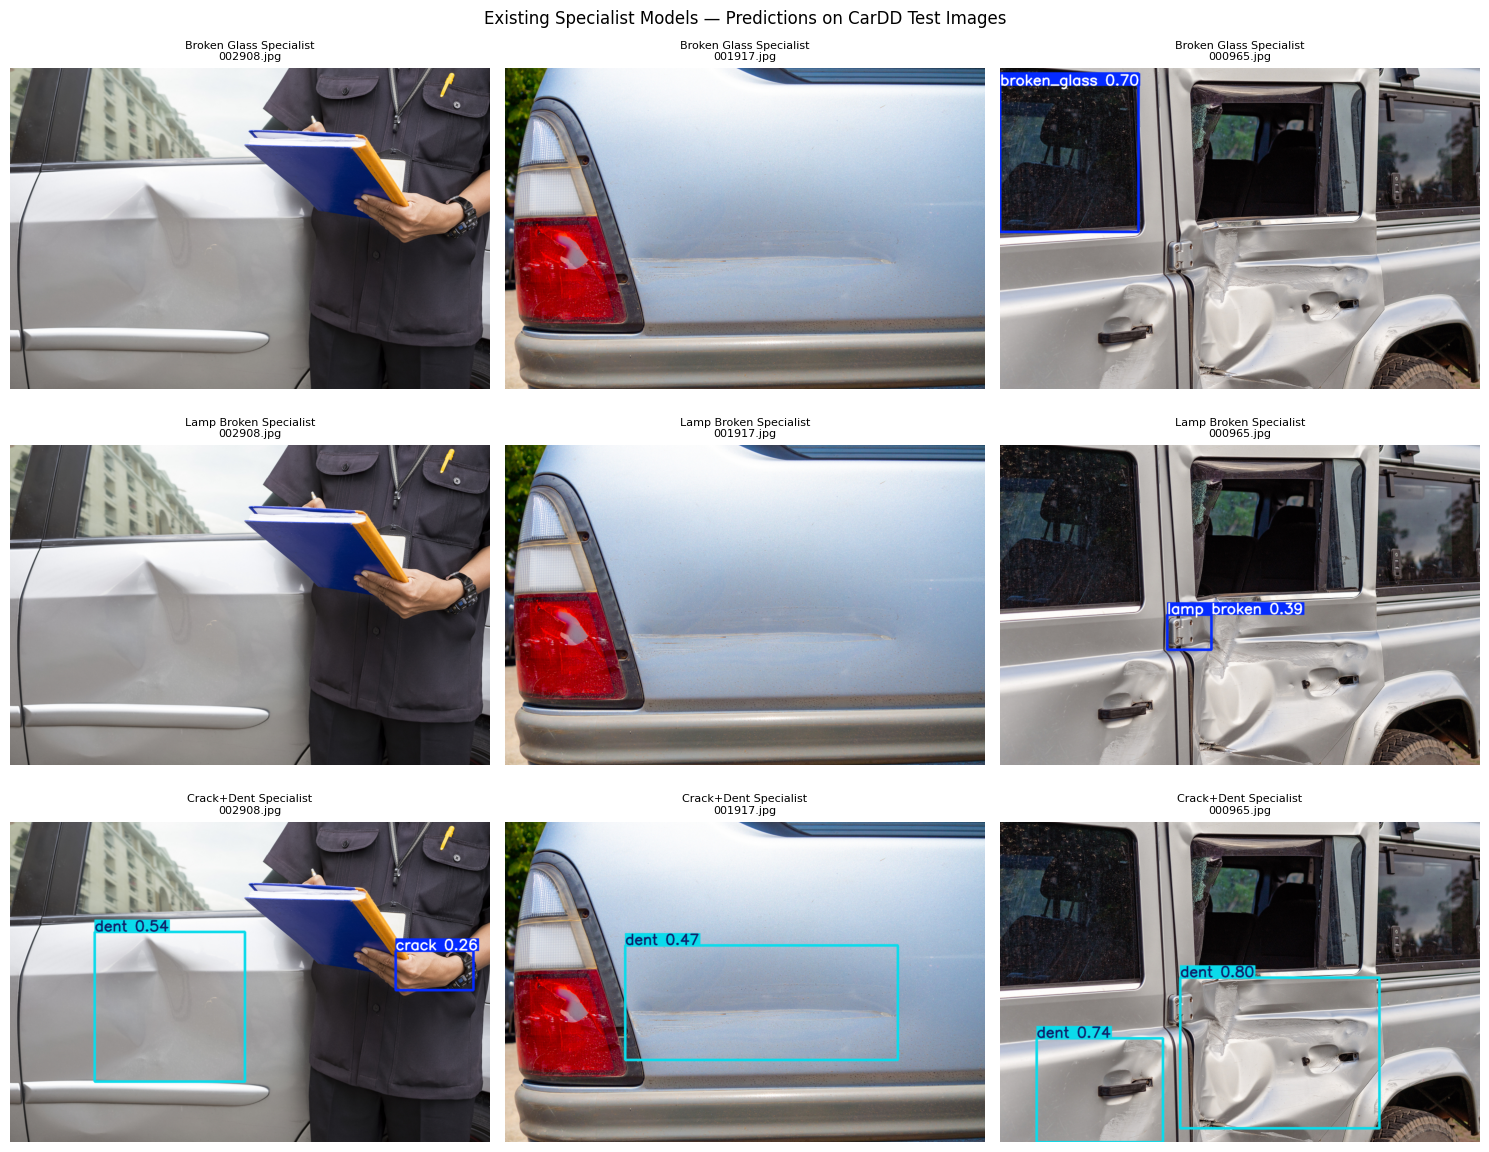


✅ Done — image saved to /content/specialist_predictions.png


In [5]:
# Cell 8 Fixed: Test existing models on sample images instead
!pip install ultralytics -q

from ultralytics import YOLO
import os, glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Rename uploaded files (Colab adds numbers)
for old, new in [('best_window (1).pt', 'best_window.pt'),
                 ('best_lamp (1).pt',   'best_lamp.pt'),
                 ('best_damage (1).pt', 'best_damage.pt')]:
    if os.path.exists(old) and not os.path.exists(new):
        os.rename(old, new)

# Grab 6 test images
test_images = glob.glob('/content/cardd/test/images/*.jpg')[:6]
if not test_images:
    test_images = glob.glob('/content/cardd/test/images/*.png')[:6]

print(f"Found {len(test_images)} test images")

# Run each specialist model on the test images
models = {
    'best_window.pt': 'Broken Glass Specialist',
    'best_lamp.pt':   'Lamp Broken Specialist',
    'best_damage.pt': 'Crack+Dent Specialist',
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row, (model_file, name) in enumerate(models.items()):
    model = YOLO(model_file)
    results = model.predict(test_images[:3], conf=0.25, verbose=False)

    for col, (img_path, result) in enumerate(zip(test_images[:3], results)):
        plotted = result.plot()
        axes[row][col].imshow(plotted[:, :, ::-1])
        axes[row][col].set_title(f"{name}\n{os.path.basename(img_path)}", fontsize=8)
        axes[row][col].axis('off')

    print(f"✅ {name}: detected objects in {len(results)} images")

plt.suptitle('Existing Specialist Models — Predictions on CarDD Test Images', fontsize=12)
plt.tight_layout()
plt.savefig('/content/specialist_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Done — image saved to /content/specialist_predictions.png")